<a href="https://colab.research.google.com/github/daveveed/Geo-Data-Science/blob/main/Japan_light_houses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing all the needed libraries

In [20]:
import os, requests, geopandas as gpd, pandas as pd, matplotlib.pyplot as plt

In [2]:
%%capture
!pip install osmnx

In [3]:
import osmnx as ox

## creating folders and downloading the data

In [4]:
data_folder = 'data'
output_folder = 'output'

if not os.path.exists(data_folder):
    os.makedirs(data_folder)
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

In [5]:
def download(url):

  filename = os.path.join(data_folder, os.path.basename(url))

  if not os.path.exists(filename):
    response = requests.get(url, allow_redirects=True)

    with open(filename, 'wb') as f:
      f.write(response.content)

    print('downloaded', filename)

In [8]:
place_name = 'Japan'
tags = {'man_made':'lighthouse'}

japan_light_houses = ox.features_from_place(place_name, tags)

/usr/local/lib/python3.12/dist-packages/osmnx/_overpass.py:271: UserWarning: This area is 2,029 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


In [9]:
output_path = os.path.join(output_folder, 'japan_light_houses.gpkg')
japan_light_houses.to_file(output_path, driver='GPKG')

In [10]:
country_url ='https://raw.githubusercontent.com/martynafford/natural-earth-geojson/master/10m/cultural/ne_10m_admin_0_countries.json'
download(country_url)

downloaded data/ne_10m_admin_0_countries.json


In [12]:
japan_light_houses.head()

geometry addr:city addr:province  \
element id                                                              
node    265049730  POINT (134.64319 34.23914)       NaN           NaN   
        289118554   POINT (135.86194 33.4716)       NaN           NaN   
        316058290  POINT (139.56482 35.28451)       NaN           NaN   
        387744952  POINT (134.69903 33.95427)       NaN           NaN   
        399909338   POINT (132.7559 34.27994)       NaN           NaN   

                  addr:quarter    man_made   name seamark:type  wikidata  \
element id                                                                 
node    265049730          NaN  lighthouse   孫崎灯台  light_major       NaN   
        289118554          NaN  lighthouse  樫野埼灯台  light_major  Q6374339   
        316058290          NaN  lighthouse    NaN  light_minor       NaN   
        387744952          NaN  lighthouse    NaN  light_minor       NaN   
        399909338          NaN  lighthouse    NaN          NaN       NaN   

                  wikipedia                 name:en  ... official_name  \
element id                                           ...                 
node    265049730       NaN                     NaN  ...           NaN   
        289118554  ja:樫野埼灯台  Kashinozaki Lighthouse  ...           NaN   
        316058290       NaN                     NaN  ...           NaN   
        387744952       NaN                     NaN  ...           NaN   
        399909338       NaN                     NaN  ...           NaN   

                  roof:colour area access viewpoint heritage  \
element id                                                     
node    265049730         NaN  NaN    NaN       NaN      NaN   
        289118554         NaN  NaN    NaN       NaN      NaN   
        316058290         NaN  NaN    NaN       NaN      NaN   
        387744952         NaN  NaN    NaN       NaN      NaN   
        399909338         NaN  NaN    NaN       NaN      NaN   

                  heritage:operator heritage:type building:colour type  
element id                                                              
node    265049730               NaN           NaN             NaN  NaN  
        289118554               NaN           NaN             NaN  NaN  
        316058290               NaN           NaN             NaN  NaN  
        387744952               NaN           NaN             NaN  NaN  
        399909338               NaN           NaN             NaN  NaN  

[5 rows x 134 columns]

In [13]:
countries = gpd.read_file(os.path.join(data_folder, 'ne_10m_admin_0_countries.json'))
countries.head()

,scalerank,featurecla,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,ADMIN,ADM0_A3,...,REGION_WB,NAME_LEN,LONG_LEN,ABBREV_LEN,TINY,HOMEPART,MIN_ZOOM,MIN_LABEL,MAX_LABEL,geometry
0,3,Admin-0 country,5.0,Netherlands,NL1,1.0,2.0,Country,Aruba,ABW,...,Latin America & Caribbean,5.0,5.0,5.0,4.0,-99.0,0.0,5.0,10.0,"POLYGON ((-69.99694 12.57758, -69.93639 12.531..."
1,0,Admin-0 country,3.0,Afghanistan,AFG,0.0,2.0,Sovereign country,Afghanistan,AFG,...,South Asia,11.0,11.0,4.0,-99.0,1.0,0.0,3.0,7.0,"POLYGON ((71.0498 38.40866, 71.05714 38.40903,..."
2,0,Admin-0 country,3.0,Angola,AGO,0.0,2.0,Sovereign country,Angola,AGO,...,Sub-Saharan Africa,6.0,6.0,4.0,-99.0,1.0,0.0,3.0,7.0,"MULTIPOLYGON (((11.73752 -16.69258, 11.73851 -..."
3,3,Admin-0 country,6.0,United Kingdom,GB1,1.0,2.0,Dependency,Anguilla,AIA,...,Latin America & Caribbean,8.0,8.0,4.0,-99.0,-99.0,0.0,5.0,10.0,"MULTIPOLYGON (((-63.03767 18.21296, -63.09952 ..."
4,0,Admin-0 country,6.0,Albania,ALB,0.0,2.0,Sovereign country,Albania,ALB,...,Europe & Central Asia,7.0,7.0,4.0,-99.0,1.0,0.0,5.0,10.0,"POLYGON ((19.74777 42.5789, 19.74601 42.57993,..."


In [14]:
japan = countries.loc[countries['SOVEREIGNT'] == 'Japan']

## Visualisation

<Axes: >

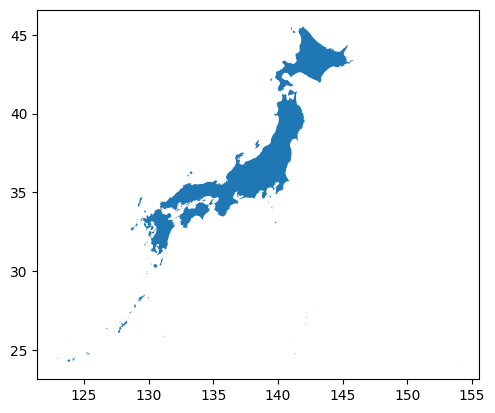

In [15]:
japan.plot()

<Axes: >

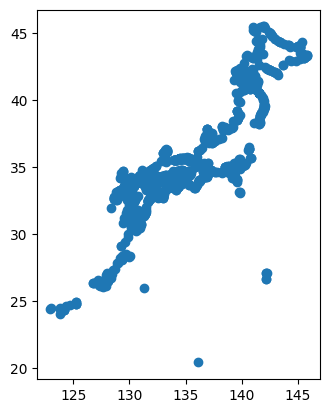

In [16]:
japan_light_houses.plot()

advance visualisation


In [62]:
import matplotlib.patheffects as pe

glow_color = '#48cae4'
glow_effects = [
    pe.Stroke(linewidth=6, foreground=glow_color, alpha=0.1), # Wider, fainter glow
    pe.Stroke(linewidth=4, foreground=glow_color, alpha=0.2),  # Medium glow
    pe.Stroke(linewidth=2, foreground=glow_color, alpha=0.5),  # Stronger glow
    pe.Normal() # The original marker will be drawn on top
]

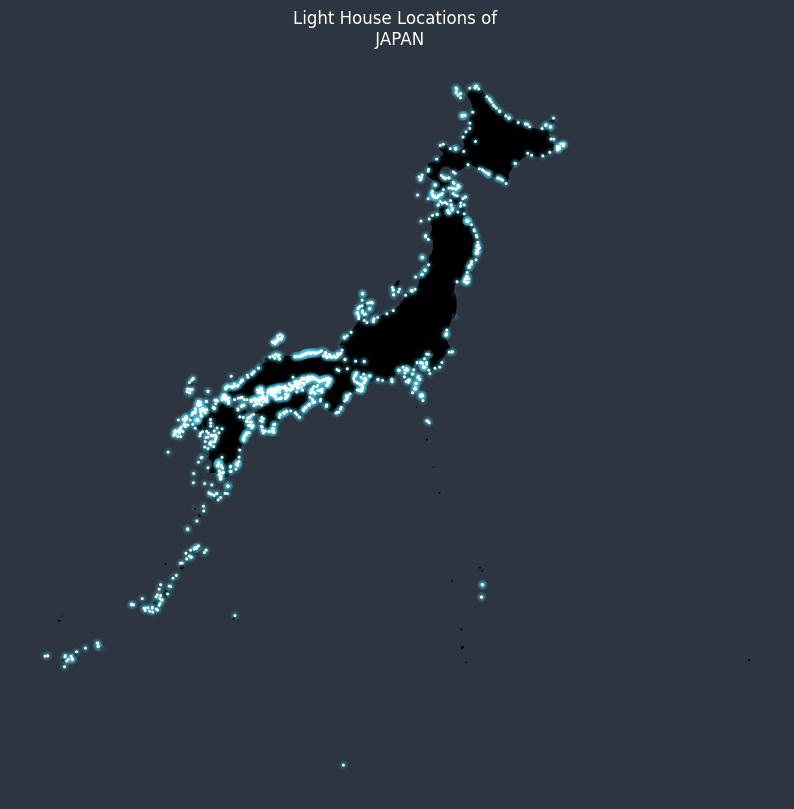

In [71]:
from numpy import size
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(10, 10)

japan.plot(ax=ax, facecolor='black', edgecolor='black')
japan_light_houses.plot(ax=ax, color='white',
                        markersize=1,
                        path_effects=glow_effects)

fig.set_facecolor('#2d3540')
ax.set_facecolor('#2d3540')
ax.set_title('Light House Locations of \n JAPAN', color='white')
ax.set_axis_off()

output_path = os.path.join(output_folder, 'japan_light_houses.png')
plt.savefig(output_path, dpi=150)
plt.show()